Load Data (Superstore Sales Dataset):

In [9]:
import pandas as pd

df = pd.read_csv("data/train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Inspect Data:

In [21]:
# Basic overview
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9800 non-null   int64         
 1   order_id       9800 non-null   str           
 2   order_date     9800 non-null   datetime64[us]
 3   ship_date      9800 non-null   datetime64[us]
 4   ship_mode      9800 non-null   str           
 5   customer_id    9800 non-null   str           
 6   customer_name  9800 non-null   str           
 7   segment        9800 non-null   str           
 8   country        9800 non-null   str           
 9   city           9800 non-null   str           
 10  state          9800 non-null   str           
 11  postal_code    9789 non-null   float64       
 12  region         9800 non-null   str           
 13  product_id     9800 non-null   str           
 14  category       9800 non-null   str           
 15  sub-category   9800 non-null   s

In [22]:
# Missing values
df.isnull().sum()

row_id            0
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
customer_name     0
segment           0
country           0
city              0
state             0
postal_code      11
region            0
product_id        0
category          0
sub-category      0
product_name      0
sales             0
dtype: int64

postcal_code has 11 missing values (less than 1% of the entire data).
This specific column is not gonna be used in the analysis, so no further actions are taken, regarding this column and its' 11 missing values.

In [23]:
# Duplicates
df.duplicated().sum()

np.int64(0)

Data Cleaning:
- Standardized column names
- Converted date columns from string (DD/MM/YYYY) to datetime format
- Removed duplicate rows

In [97]:
# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")

# Convert date columns
df["order_date"] = pd.to_datetime(df["order_date"], format="%d/%m/%Y")
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%d/%m/%Y")

# Remove duplicate rows
df = df.drop_duplicates()

# Check cleaned data
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9800 non-null   int64         
 1   order_id       9800 non-null   str           
 2   order_date     9800 non-null   datetime64[us]
 3   ship_date      9800 non-null   datetime64[us]
 4   ship_mode      9800 non-null   str           
 5   customer_id    9800 non-null   str           
 6   customer_name  9800 non-null   str           
 7   segment        9800 non-null   str           
 8   country        9800 non-null   str           
 9   city           9800 non-null   str           
 10  state          9800 non-null   str           
 11  postal_code    9789 non-null   float64       
 12  region         9800 non-null   str           
 13  product_id     9800 non-null   str           
 14  category       9800 non-null   str           
 15  sub_category   9800 non-null   s

SQL Queries:

In [98]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False)


9800

Query 1 - Total Sales by Category

In [99]:
query_total_sales_by_category = """
SELECT category, SUM(sales) AS total_sales
FROM sales
GROUP BY category
"""

total_sales_by_category = pd.read_sql(query_total_sales_by_category, conn)
total_sales_by_category

,category,total_sales
0,Furniture,728658.5757
1,Office Supplies,705422.3340
2,Technology,827455.8730


Query 2 - Top 5 Products by Total Sales

In [100]:
query_top_5_products_by_total_sales = """
SELECT product_name, SUM(sales) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_sales DESC
LIMIT 5;
"""

top_5_products_by_total_sales = pd.read_sql(query_top_5_products_by_total_sales, conn)
top_5_products_by_total_sales

,product_name,total_sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479


Query 3 - Sales over time

In [101]:
query_sales_over_time = """
SELECT strftime('%Y-%m', order_date) AS order_month, SUM(sales) AS total_sales
FROM sales
GROUP BY order_month
ORDER BY order_month ASC
"""

sales_over_time = pd.read_sql(query_sales_over_time, conn)
sales_over_time

,order_month,total_sales
0,2015-01,14205.7070
1,2015-02,4519.8920
2,2015-03,55205.7970
3,2015-04,27906.8550
4,2015-05,23644.3030
5,2015-06,34322.9356
6,2015-07,33781.5430
7,2015-08,27117.5365
8,2015-09,81623.5268
9,2015-10,31453.3930


Query 4 - Total Sales per Region

In [102]:
query_total_sales_per_region = """
SELECT region, SUM(sales) AS sales_per_region
FROM sales
GROUP BY region
"""

total_sales_per_region = pd.read_sql(query_total_sales_per_region, conn)
total_sales_per_region

,region,sales_per_region
0,Central,492646.9132
1,East,669518.7260
2,South,389151.4590
3,West,710219.6845


Query 5 - Total Sales by Customer Segment

In [103]:
query_total_sales_by_customer_segment = """
SELECT segment, SUM(sales) AS sales_per_segment
FROM sales
GROUP BY segment
"""

total_sales_by_customer_segment = pd.read_sql(query_total_sales_by_customer_segment, conn)
total_sales_by_customer_segment

,segment,sales_per_segment
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


Query 6 - Top 5 Customers by Total Sales

In [104]:
query_top_5_customers_by_total_sales = """
SELECT customer_name, SUM(sales) AS total_sales_for_customer
FROM sales
GROUP BY customer_name
ORDER BY total_sales_for_customer DESC
LIMIT 5;
"""

top_5_customers_by_total_sales = pd.read_sql(query_top_5_customers_by_total_sales, conn)
top_5_customers_by_total_sales

,customer_name,total_sales_for_customer
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571


Query 7 - Average Sales per Order

In [105]:
query_average_sales_per_order = """
SELECT AVG(sum_of_sales) AS average_sales
FROM (SELECT order_id, SUM(sales) AS sum_of_sales
    FROM sales
    GROUP BY order_id)
"""

average_sales_per_order = pd.read_sql(query_average_sales_per_order, conn)
average_sales_per_order

,average_sales
0,459.475169


Query 8 - Sales by Sub-Category

In [107]:
query_sales_by_sub_category = """
SELECT sub_category, SUM(sales) AS sum_of_sales
FROM sales
GROUP BY sub_category
"""

sales_by_sub_category = pd.read_sql(query_sales_by_sub_category, conn)
sales_by_sub_category

,sub_category,sum_of_sales
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987
5,Chairs,322822.7310
6,Copiers,146248.0940
7,Envelopes,16128.0460
8,Fasteners,3001.9600
9,Furnishings,89212.0180


Query 9 - Monthly Sales Growth

In [108]:
query_monthly_sales_growth = """
WITH monthly_sales AS (
    SELECT strftime('%Y-%m', order_date) AS order_month, SUM(sales) AS total_sales
    FROM sales
    GROUP BY order_month
),
monthly_sales_with_previous AS (
    SELECT
        order_month,
        total_sales,
        LAG(total_sales) OVER (ORDER BY order_month) AS previous_month_sales
    FROM monthly_sales
)
SELECT
    order_month,
    total_sales,
    previous_month_sales,
    total_sales - previous_month_sales AS monthly_growth
FROM monthly_sales_with_previous
ORDER BY order_month ASC;
"""

monthly_sales_growth = pd.read_sql(query_monthly_sales_growth, conn)
monthly_sales_growth

,order_month,total_sales,previous_month_sales,monthly_growth
0,2015-01,14205.7070,NaN,NaN
1,2015-02,4519.8920,14205.7070,-9685.8150
2,2015-03,55205.7970,4519.8920,50685.9050
3,2015-04,27906.8550,55205.7970,-27298.9420
4,2015-05,23644.3030,27906.8550,-4262.5520
5,2015-06,34322.9356,23644.3030,10678.6326
6,2015-07,33781.5430,34322.9356,-541.3926
7,2015-08,27117.5365,33781.5430,-6664.0065
8,2015-09,81623.5268,27117.5365,54505.9903
9,2015-10,31453.3930,81623.5268,-50170.1338


Visualizations

Bar Chart of Sales by Category:

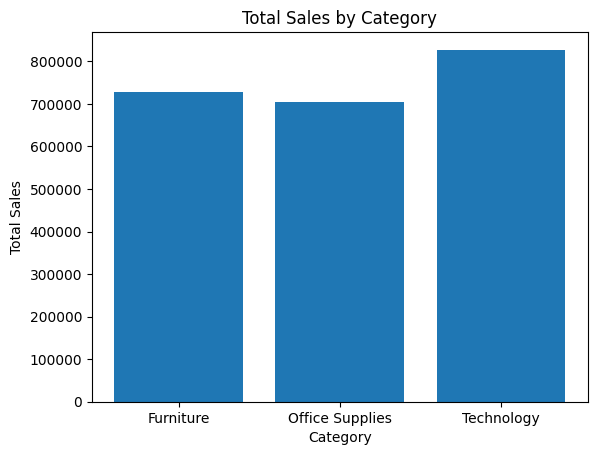

In [110]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(total_sales_by_category["category"], total_sales_by_category["total_sales"])

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

Line Chart of Monthly Sales Trend

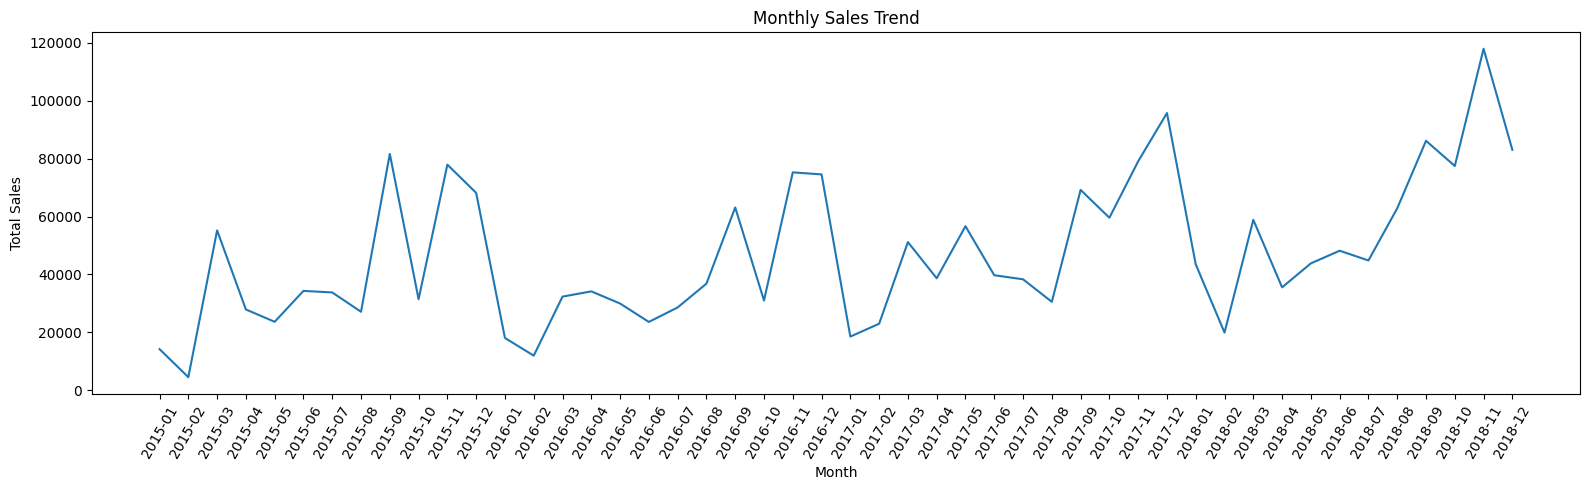

In [130]:
plt.figure(figsize=(16, 5))

plt.plot(monthly_sales_growth["order_month"], monthly_sales_growth["total_sales"])

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(monthly_sales_growth["order_month"][::1], rotation=60)
plt.tight_layout()

plt.show()

Bar Chart of Top 5 Products

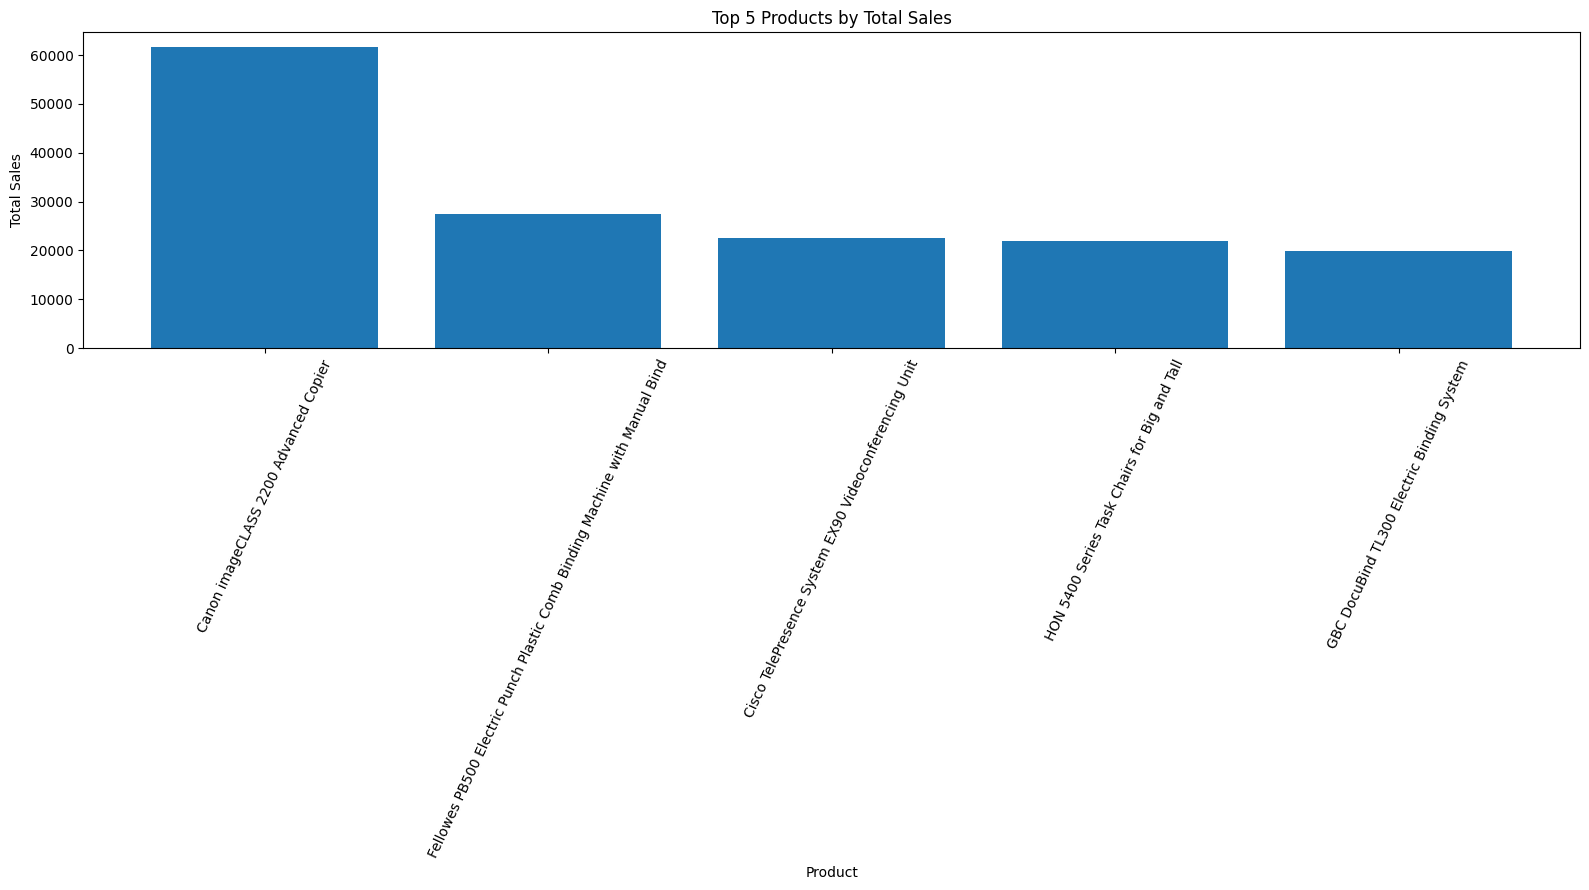

In [135]:
plt.figure(figsize=(16, 9))

plt.bar(top_5_products_by_total_sales["product_name"],
        top_5_products_by_total_sales["total_sales"])

plt.title("Top 5 Products by Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=65)
plt.tight_layout()

plt.show()

Insights:

- The product Canon imageCLASS 2200 Advanced Copier is one of the top contributors to total sales, indicating some level of product concentration.

- Sales show an overall upward trend over time, hinting at business growth, although there are noticeable fluctuations between months.

- There is clear volatility in monthly sales, with sharp increases and drops, indicating possible seasonality or irregular demand patterns.

- Sales are relatively evenly distributed across categories, although Technology generates the highest total sales.

- Growth is not consistent month-to-month, highlighting potential opportunities for improving sales stability and forecasting.